<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/nsl_kdd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# CELL 1: Mount Drive and setup
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# Clone your GitHub repo to get your config file
!git clone https://github.com/i10770e/xai-ids.git
%cd xai-ids

print("✅ Setup complete!")

Mounted at /content/drive
Cloning into 'xai-ids'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'xai-ids'
/content
✅ Setup complete!


In [2]:
# ============================================
# CELL 2: Download NSL-KDD dataset
# ============================================
import pandas as pd
import requests
from pathlib import Path

print("📥 Downloading NSL-KDD dataset...")

# URLs for the dataset
train_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
test_url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"

# Column names for NSL-KDD
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Download training data
print("Downloading training set...")
df_train = pd.read_csv(train_url, names=columns)
print(f"✅ Training set: {df_train.shape}")

# Download test data
print("Downloading test set...")
df_test = pd.read_csv(test_url, names=columns)
print(f"✅ Test set: {df_test.shape}")

# Show first few rows
print("\n📊 First 5 rows of training data:")
print(df_train.head())

📥 Downloading NSL-KDD dataset...
✅ Training set: (125973, 43)
✅ Test set: (22544, 43)

📊 First 5 rows of training data:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0         

In [3]:
# ============================================
# CELL 3: Add binary and multi-class labels
# ============================================

# Create binary labels (0 = normal, 1 = attack)
df_train['binary_label'] = (df_train['label'] != 'normal').astype(int)
df_test['binary_label'] = (df_test['label'] != 'normal').astype(int)

# Create attack categories
attack_categories = {
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS',
    'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'satan': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    'buffer_overflow': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L',
    'multihop': 'R2L', 'phf': 'R2L', 'spy': 'R2L',
    'warezclient': 'R2L', 'warezmaster': 'R2L', 'sendmail': 'R2L',
    'named': 'R2L', 'snmpgetattack': 'R2L', 'snmpguess': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'worm': 'R2L',
    'httptunnel': 'R2L',
    'rootkit': 'U2R', 'perl': 'U2R', 'sqlattack': 'U2R',
    'xterm': 'U2R', 'ps': 'U2R'
}

df_train['attack_category'] = df_train['label'].map(attack_categories).fillna('BENIGN')
df_test['attack_category'] = df_test['label'].map(attack_categories).fillna('BENIGN')

print("\n📊 Class distribution:")
print(df_train['binary_label'].value_counts())
print(f"\nAttack categories:\n{df_train['attack_category'].value_counts()}")


📊 Class distribution:
binary_label
0    67343
1    58630
Name: count, dtype: int64

Attack categories:
attack_category
BENIGN    67360
DoS       45927
Probe     11656
R2L        1017
U2R          13
Name: count, dtype: int64


In [4]:
# ============================================
# CELL 4: Save to Google Drive
# ============================================

# Save to Drive
train_path = '/content/drive/MyDrive/xai-ids/data/raw/nsl_kdd_train.pkl'
test_path = '/content/drive/MyDrive/xai-ids/data/raw/nsl_kdd_test.pkl'

df_train.to_pickle(train_path)
df_test.to_pickle(test_path)

print(f"✅ Training data saved to: {train_path}")
print(f"✅ Test data saved to: {test_path}")

# Also save as CSV for easy viewing
df_train.to_csv('/content/drive/MyDrive/xai-ids/data/raw/nsl_kdd_train.csv', index=False)
print("✅ Also saved as CSV for easy viewing")

✅ Training data saved to: /content/drive/MyDrive/xai-ids/data/raw/nsl_kdd_train.pkl
✅ Test data saved to: /content/drive/MyDrive/xai-ids/data/raw/nsl_kdd_test.pkl
✅ Also saved as CSV for easy viewing


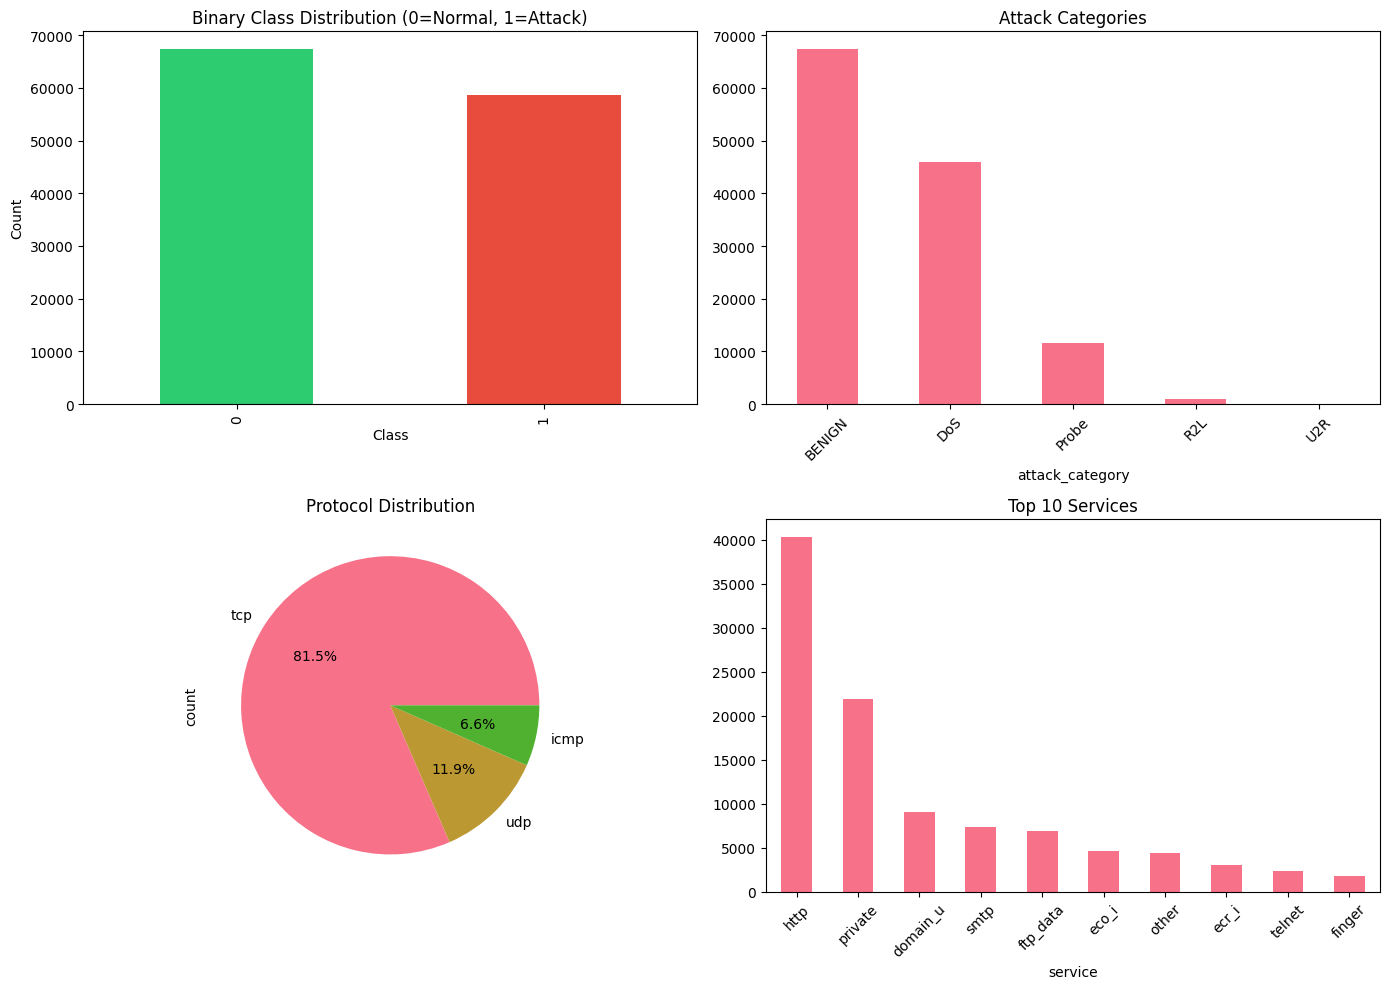

✅ EDA plot saved to Drive


In [5]:
# ============================================
# CELL 5: Quick visualization
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Class distribution
df_train['binary_label'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Binary Class Distribution (0=Normal, 1=Attack)')
axes[0,0].set_xlabel('Class')
axes[0,0].set_ylabel('Count')

# Plot 2: Attack categories
df_train['attack_category'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Attack Categories')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Protocol distribution
protocol_counts = df_train['protocol_type'].value_counts()
protocol_counts.plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Protocol Distribution')

# Plot 4: Service distribution (top 10)
df_train['service'].value_counts().head(10).plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Top 10 Services')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/nsl_kdd_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot saved to Drive")